# ****Unsupervised Learning : Driving behaviour classification****

## Context

In an increasingly digitized world, road safety remains a paramount concern. With the proliferation of smart devices and IoT sensors, vast amounts of driving data are being generated every day. Leveraging this wealth of information, our project aims to develop a machine learning model that can analyze driving behavior based on data collected from vehicles on the road. By classifying these behaviors into categories such as normal, relaxed, and aggressive, we can provide valuable insights into driver habits and potentially mitigate risks associated with unsafe driving practices.

By accurately identifying aggressive driving behaviors such as sudden acceleration, harsh braking, and erratic lane changes, our model can help in early detection of risky situations, thereby preventing accidents and saving lives. Also, Aggressive driving behaviors are often associated with higher fuel consumption and emissions. By promoting smoother, more relaxed driving styles, our project can contribute to reducing carbon emissions and mitigating environmental impact associated with transportation.

Therefore, by classifying driving behaviors we seek to leverage this information for the betterment of road safety, environmental sustainability, and overall efficiency in transportation systems.

## Objective


The objective of this project is to develop a machine learning model capable of accurately detecting and classifying driving behaviors based data collected from vehicles on the road. The model will classify driving behaviors into categories such as normal, relaxed, and aggressive, with the aim of providing valuable insights into driver habits. By achieving this objective, we aim to enhance road safety, promote responsible driving practices,and contribute to the optimized use of fuel to enhance enviroment sustainability.

## Data Dictionary

1.**trip_distance**
  - Description: The distance, measured in kilometers (kms), covered by the vehicle during the entire trip. This metric provides insight into the overall length of the journey, capturing both short and long-distance travels. It is calculated based on the cumulative distance traveled from the starting point to the destination, offering a fundamental measure of the extent of the trip's spatial coverage.
  - Data Type: Decimal
  - Units: kilometers (kms)
  - Range: Positive decimal numbers
  
2.**rapid_acceleration**
  - Description: The count of instances where the vehicle experienced rapid acceleration during the trip. Rapid acceleration refers to sudden increases in velocity over short time intervals, indicative of aggressive driving behavior. This metric helps identify driving patterns characterized by frequent bursts of acceleration, which may contribute to increased fuel consumption, wear and tear on the vehicle, and heightened safety risks.
  - Data Type: Integer
  - Units: None
  - Range: Non-negative integers
  
3.**sudden_stops**
  - Description: The count of instances where the vehicle underwent sudden stops or abrupt deceleration during the trip. Sudden stops occur when the vehicle rapidly reduces its speed, potentially indicating emergency braking or reckless driving behavior. Monitoring this metric helps detect driving habits associated with tailgating, distracted driving, or poor anticipation of traffic conditions, all of which pose risks to road safety.
  - Data Type: Integer
  - Units: None
  - Range: Non-negative integers
  
4.**sharp_turn**
  - Description: The count of sharp turns executed by the vehicle during the trip. A sharp turn is characterized by a significant change in direction or trajectory, often involving high lateral acceleration. This metric provides insights into driving behaviors associated with aggressive maneuvering, such as speeding around corners or weaving through traffic, which may increase the likelihood of accidents or loss of vehicle control.
  - Data Type: Integer
  - Units: None
  - Range: Non-negative integers
  
5.**over_speed**
  - Description: The total duration, measured in milliseconds (ms), during which the vehicle exceeded the speed limit or operated at speeds deemed excessive for the prevailing road conditions. Over-speeding poses significant safety risks and may result in traffic violations, collisions, or loss of vehicle control. Monitoring this metric helps identify instances of reckless driving behavior and assess compliance with speed regulations.
  - Data Type: Long Float
  - Units: milliseconds (ms)
  - Range: Positive long floating-point numbers
  
6.**night_drive**
  - Description: The total duration, measured in milliseconds (ms), of driving performed during nighttime hours, typically defined as the period between sunset and sunrise. Night driving presents unique challenges, including reduced visibility, increased risk of fatigue, and higher likelihood of encountering impaired or intoxicated drivers. Monitoring this metric enables assessment of driving habits during low-light conditions and identification of potential safety concerns associated with night-time travel.
  - Data Type: Long Float
  - Units: milliseconds (ms)
  - Range: Positive long floating-point numbers
  
7. **trip_duration**

- Description: The total duration of the trip, measured in milliseconds (ms). This metric captures the overall time spent on the trip, encompassing all driving segments from the starting point to the destination. It provides a valuable reference point for interpreting other trip-related metrics, such as average speed, fuel efficiency, and driving behavior patterns.
- Data Type: Long Float
- Units: milliseconds (ms)
- Range: Positive long floating-point numbers

## Importing necessary libraries and data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Suppress specific future warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

# Fix the random seed for consistency
np.random.seed(42)

## Generation of sample data
  
- **Data Generation Function**: 
  - The function `generate_driving_data` is defined to create dummy data for each driving style based on specified parameters.
  - It takes two arguments: `style`, indicating the driving style, and `num_samples`, denoting the number of samples to generate for each style.
  
- **Driving Style Categories**:
  - For each driving style (`aggressive`, `normal`, `relaxed`), the function generates synthetic data comprising the following features:
    - `trip_distance_km`: Distance covered during the trip in kilometers.
    - `overspeed_ms`: Duration of overspeeding in milliseconds.
    - `night_driving_ms`: Duration of night driving in milliseconds.
    - `rapid_acceleration`: Count of instances of rapid acceleration.
    - `sharp_turns`: Count of sharp turns.
    - `sudden_stops`: Count of sudden stops.
    - `trip_duration_ms` : Duration of the trip
- **Data Generation Parameters**:
  - Synthetic data is generated using numpy's random functions with specified ranges and distributions for each driving style.
  - Parameters such as trip distance, duration of overspeeding, and counts of driving maneuvers vary depending on the driving style.

- **Data Collection**:
  - Data is generated for each driving style (`aggressive`, `normal`, `relaxed`) by calling the `generate_driving_data` function with appropriate parameters.

- **Sample Size**:
  - The number of samples per driving style is specified by the variable `num_samples_per_style`, set to 5000 in this case.

- **Output**:
  - Separate datasets (`aggressive_data`, `normal_data`, `relaxed_data`) are generated, each containing synthetic driving data corresponding to the respective driving style.
  
The data is being generated with conditions for normal, aggressive and relaxed driving styles so that the data contains covers all types of driving styles.

In [3]:
# Generate synthetic driving data
num_samples_per_style = 5000

def generate_driving_data(style, num_samples):
    if style == 'aggressive':
        night_driving_ms = np.random.uniform(1800000, 3600000, num_samples)
        overspeed_ms = np.random.uniform(200000, 600000, num_samples)
        trip_duration_ms = np.maximum(night_driving_ms, overspeed_ms) + np.random.uniform(0, 7200000, num_samples)
        return {
            "trip_distance_km": np.random.uniform(2, 70, num_samples),
            "overspeed_ms": overspeed_ms,
            "night_driving_ms": night_driving_ms,
            "rapid_acceleration": np.random.randint(20, 50, num_samples),
            "sharp_turns": np.random.randint(20, 50, num_samples),
            "sudden_stops": np.random.randint(10, 30, num_samples),
            "trip_duration_ms": trip_duration_ms
        }
    elif style == 'normal':
        night_driving_ms = np.random.uniform(900000, 1800000, num_samples)
        overspeed_ms = np.random.uniform(50000, 200000, num_samples)
        trip_duration_ms = np.maximum(night_driving_ms, overspeed_ms) + np.random.uniform(0, 7200000, num_samples)
        return {
            "trip_distance_km": np.random.uniform(2, 70, num_samples),
            "overspeed_ms": overspeed_ms,
            "night_driving_ms": night_driving_ms,
            "rapid_acceleration": np.random.randint(5, 20, num_samples),
            "sharp_turns": np.random.randint(5, 20, num_samples),
            "sudden_stops": np.random.randint(5, 10, num_samples),
            "trip_duration_ms": trip_duration_ms
        }
    elif style == 'relaxed':
        night_driving_ms = np.random.uniform(0, 900000, num_samples)
        overspeed_ms = np.random.uniform(0, 50000, num_samples)
        trip_duration_ms = np.maximum(night_driving_ms, overspeed_ms) + np.random.uniform(0, 7200000, num_samples)
        return {
            "trip_distance_km": np.random.uniform(2, 70, num_samples),
            "overspeed_ms": overspeed_ms,
            "night_driving_ms": night_driving_ms,
            "rapid_acceleration": np.random.randint(0, 5, num_samples),
            "sharp_turns": np.random.randint(0, 5, num_samples),
            "sudden_stops": np.random.randint(0, 5, num_samples),
            "trip_duration_ms": trip_duration_ms
        }

aggressive_data = generate_driving_data('aggressive', num_samples_per_style)
normal_data = generate_driving_data('normal', num_samples_per_style)
relaxed_data = generate_driving_data('relaxed', num_samples_per_style)

# Convert to DataFrames
aggressive_df = pd.DataFrame(aggressive_data)
normal_df = pd.DataFrame(normal_data)
relaxed_df = pd.DataFrame(relaxed_data)

aggressive_df['driving_behavior'] = 'aggressive'
normal_df['driving_behavior'] = 'normal'
relaxed_df['driving_behavior'] = 'relaxed'

# Combine DataFrames
combined_df = pd.concat([aggressive_df, normal_df, relaxed_df], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Replace infinite values with NaNs
combined_df.replace([np.inf, -np.inf], np.nan, inplace=True)

print(combined_df.shape)
print(combined_df.head())

(15000, 8)
   trip_distance_km   overspeed_ms  night_driving_ms  rapid_acceleration  \
0         62.478186   34508.646332      3.378864e+05                   1   
1         18.101889  177657.707943      9.510762e+05                  16   
2         58.988342    7195.375295      6.220517e+05                   3   
3         41.991587  202985.256167      2.743902e+06                  39   
4         63.299398   78818.135182      1.760022e+06                  17   

   sharp_turns  sudden_stops  trip_duration_ms driving_behavior  
0            3             4      4.178482e+06          relaxed  
1           11             7      6.963062e+06           normal  
2            0             1      2.579871e+06          relaxed  
3           24            10      3.522553e+06       aggressive  
4            8             7      8.526886e+06           normal  


## Exploratory Data Analysis (EDA) for Driving Behavior Detection Project

- EDA plays a crucial role in understanding the driving behavior dataset thoroughly before proceeding with model development.
  
- Investigating and comprehending the characteristics and patterns within the data is essential for building an effective driving behavior detection model.

- Below are some guiding questions to help approach the analysis systematically and derive meaningful insights from the driving behavior dataset:

1. **What is the distribution of driving behavior metrics?**
   - Explore the distribution of features such as trip distance, duration of overspeeding, counts of rapid accelerations, sharp turns, and sudden stops. Understanding these distributions can provide insights into the typical driving behaviors observed in the dataset.

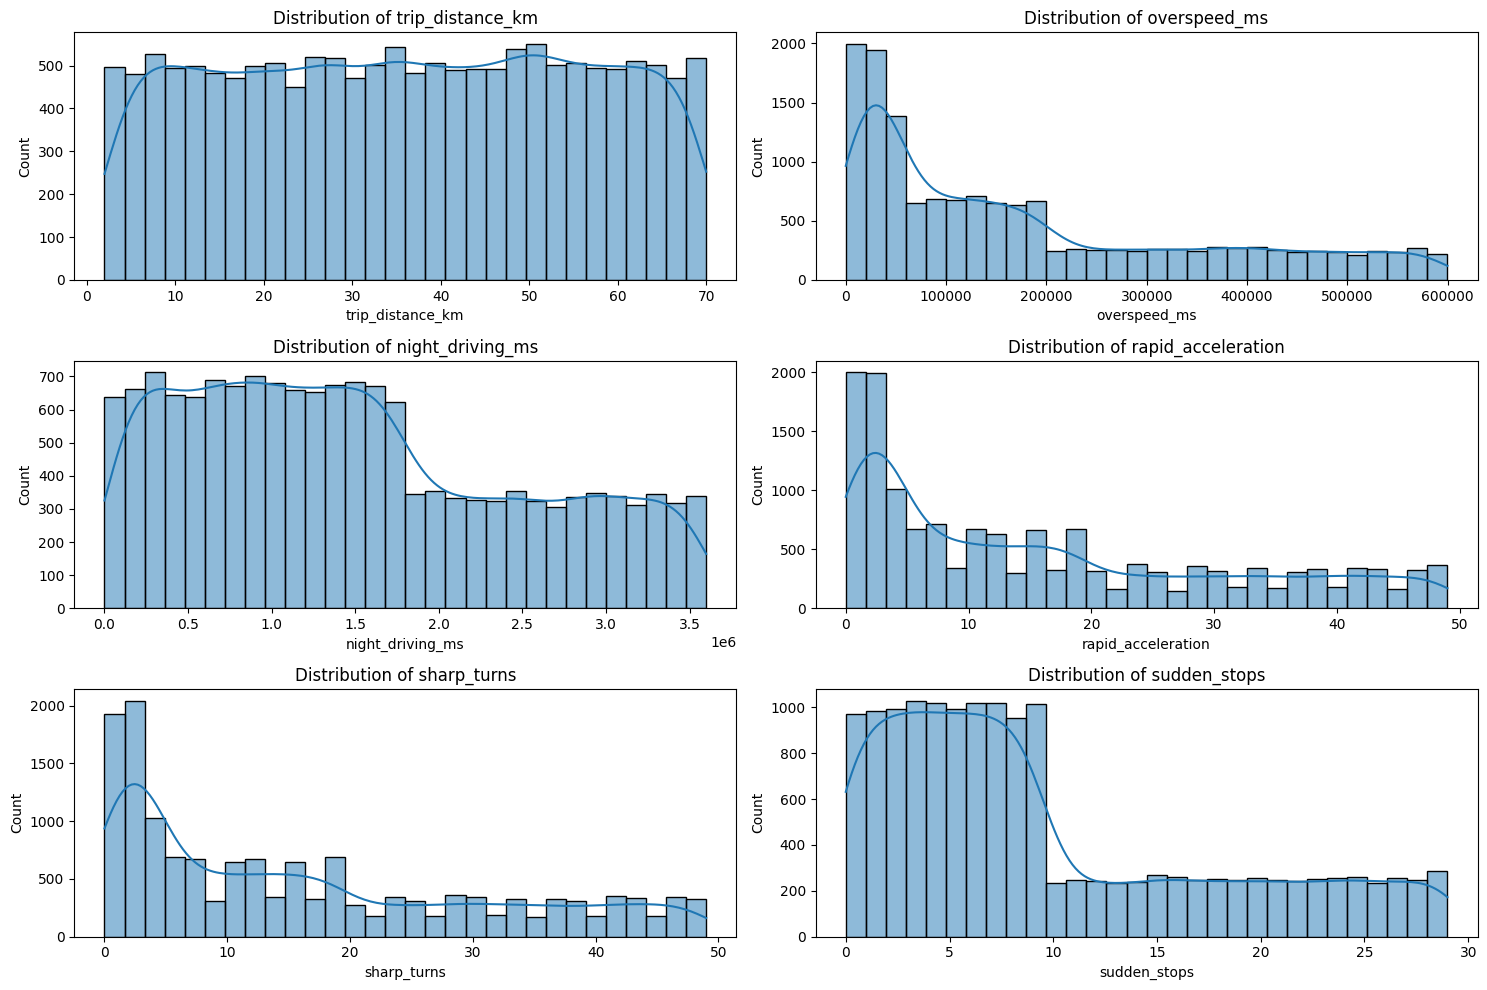

In [4]:
# 1. Distribution of driving behavior metrics
plt.figure(figsize=(15, 10))
metrics = ['trip_distance_km', 'overspeed_ms', 'night_driving_ms', 'rapid_acceleration', 'sharp_turns', 'sudden_stops']
for i, metric in enumerate(metrics, 1):
    plt.subplot(3, 2, i)
    sns.histplot(combined_df[metric], kde=True, bins=30)
    plt.title(f'Distribution of {metric}')
plt.tight_layout()
plt.show()

2. **Which driving behaviors are most prevalent across different driving styles?**
   - Analyze the frequency and distribution of driving behaviors (e.g., rapid accelerations, sudden stops) within each driving style category (aggressive, normal, relaxed). Identifying prevalent behaviors for each driving style can help characterize their distinct driving patterns.

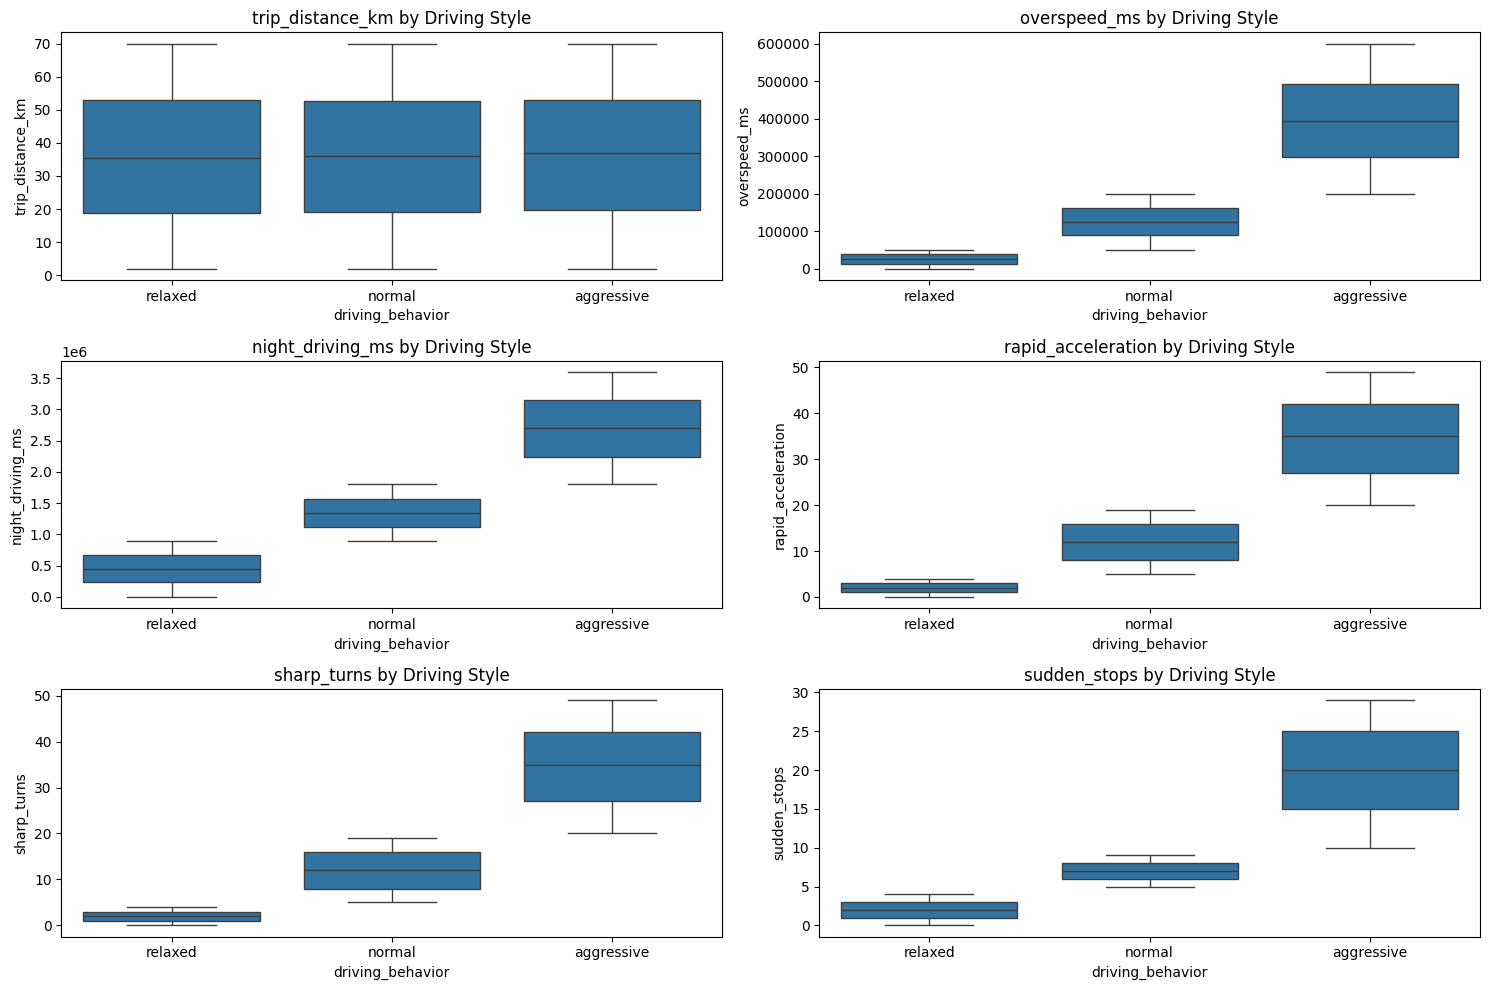

In [5]:
# 2. Prevalence of driving behaviors across different driving styles
plt.figure(figsize=(15, 10))
for i, metric in enumerate(metrics, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(data=combined_df, x='driving_behavior', y=metric)
    plt.title(f'{metric} by Driving Style')
plt.tight_layout()
plt.show()


3. **How do driving behavior metrics correlate with each other?**
   - Investigate the correlations between different driving behavior metrics (e.g., trip distance, overspeed duration, rapid accelerations). Understanding these relationships can reveal underlying patterns and dependencies in driving behavior.

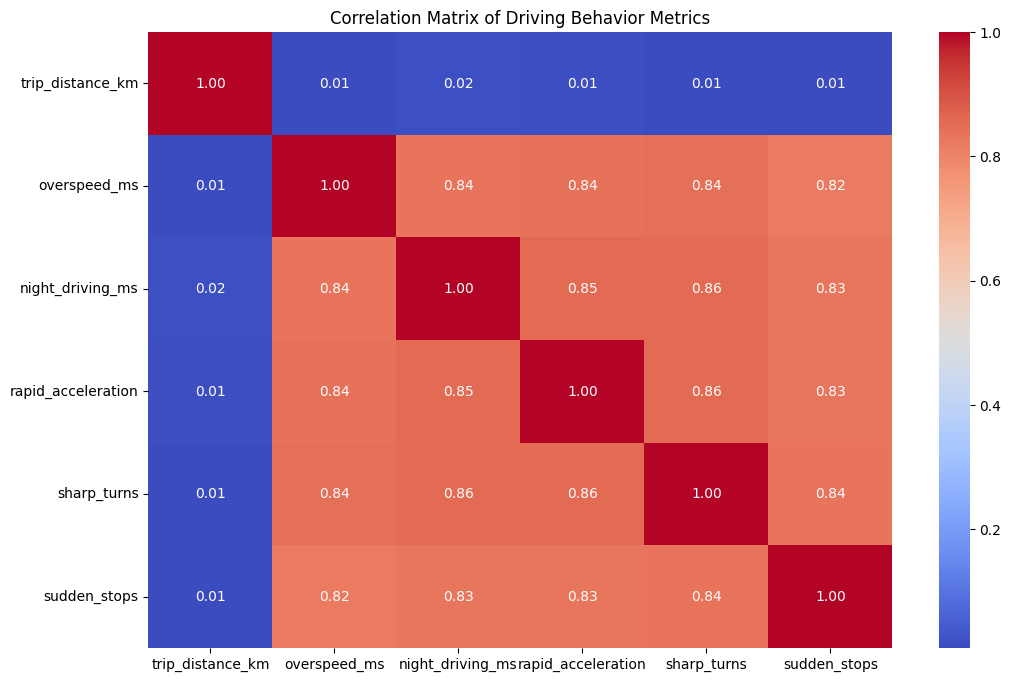

In [6]:
# 3. Correlations between driving behavior metrics
plt.figure(figsize=(12, 8))
correlation_matrix = combined_df[metrics].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Driving Behavior Metrics')
plt.show()


## Data Preprocessing

**Unit Conversion**: Converts milliseconds (ms) in the night_driving_ms and overspeed_ms columns to minutes (min). It achieves this by multiplying by a factor of 0.001 (conversion from milliseconds to seconds) and then by 0.167 (seconds to minutes).

**Downweighting Night Driving**: The code assigns less weight to the night_driving_ms feature by multiplying it by 0.1. This suggests that night driving might be considered a less significant factor compared to other features in the analysis.

**Upweighing Sudden Stops**: The code assigns more weight to the sudden_stops feature by multiplying it by 2. This suggests that sudden stops is considered a more significant factor compared to other features in the analysis.

Overall, this code snippet prepares the driving data for further analysis by converting units, potentially reducing the influence of night driving duration, and scaling the features.

In [7]:
# Normalize the features
combined_df['night_driving_ms'] = combined_df['night_driving_ms'] * 0.001 * 0.167 * 0.2
combined_df['overspeed_ms'] = combined_df['overspeed_ms'] * 0.001 * 0.167
combined_df['trip_duration_ms'] = combined_df['trip_duration_ms'] * 0.001 * 0.167
combined_df['sudden_stops'] = combined_df['sudden_stops'] * 2 

# Replace infinite values with NaNs
combined_df.replace([np.inf, -np.inf], np.nan, inplace=True)



## Function Description for calculate_driving_score(data)

This function calculates a driving score based on various driving behavior metrics provided in a data dictionary using the following formula:

**Score = Starting Score + Distance Bonus - Event Penalty**

**Formula Breakdown:**

* **Starting Score (`startingscore`):** This is the baseline score assigned to every trip.
* **Distance Bonus:** This term rewards longer trips up to a maximum score (`topscore`). It is calculated as the logarithm of (1 + trip distance in kilometers) multiplied by coefficient `A`, capped at the difference between the starting score and the maximum score using the `np.minimum` function.
    * `A`: This coefficient controls the weight of the distance factor in the overall score. Higher values of `A` will result in a larger bonus for longer trips.

* **Event Penalty:** This term penalizes the score based on the frequency and severity of driving events. It is calculated using the following formula:

    ```
    Event Penalty = B * ln(1 + C * (Event Count) / (1 + Trip Distance))
    ```

    * `B`: This coefficient controls the overall severity of the penalty. Higher values of `B` will result in a harsher penalty for frequent events.
    * `C`: This coefficient scales the event count based on the trip distance. A lower value of `C` will put more emphasis on events relative to longer trips.
    * `Event Count`: This is the sum of:
        * Rapid acceleration count.
        * Sudden stop count.
        * Overspeeding penalty (scaled by `overspeed_proportion`).
        * Night driving penalty (scaled by `night_driving_proportion`).
        * Sharp turn count.

* `ln`: The natural logarithm function.

**Combining Bonus and Penalty:**

The final score is calculated by adding the distance bonus to the starting score and then subtracting the event penalty. The `np.minimum` function ensures the score stays within the range of 0 (worst) to the maximum achievable score (`topscore`) (best).

**Parameters:**

* `data` (dict): A dictionary containing the following keys (all values are assumed to be NumPy arrays):
    * "trip_distance_km": Trip distances in kilometers (km).
    * "rapid_acceleration": Count of rapid acceleration events.
    * "sudden_stops": Count of sudden stops.
    * "overspeed_ms": Total duration of overspeeding in milliseconds (ms).
    * "night_driving_ms": Total duration of night driving in milliseconds (ms).
    * "sharp_turns": Count of sharp turns.
    * "trip_duration_ms": Total trip duration in milliseconds (ms).

**Returns:**

* A float value representing the calculated driving score.


In [8]:
def calculate_driving_score(data):
    startingscore = 80
    topscore = 100
    A = 25
    B = 17
    C = 0.95
    
    trip_distance_km = data['trip_distance_km']
    rapid_acceleration = data['rapid_acceleration']
    sudden_stops = data['sudden_stops']
    overspeed_ms = data['overspeed_ms']
    night_driving_ms = data['night_driving_ms']
    sharp_turns = data['sharp_turns']
    trip_duration_ms = data['trip_duration_ms']
    
    overspeed_proportion = overspeed_ms / trip_duration_ms
    night_driving_proportion = night_driving_ms / trip_duration_ms
    
    sum_of_event_counts = (rapid_acceleration + sudden_stops + 
                           overspeed_ms * overspeed_proportion + 
                           night_driving_ms * night_driving_proportion + 
                           sharp_turns)
    
    score = (startingscore 
             + np.minimum((topscore - startingscore), A * np.log(1 + trip_distance_km)) 
             - np.minimum(startingscore, B * np.log(1 + C * (sum_of_event_counts) / (1 + trip_distance_km))))
    
    return score

combined_df['driving_score'] = combined_df.apply(calculate_driving_score, axis=1)

**Clustering Driving Behavior with KMeans**

This code utilizes KMeans clustering to group the reduced-dimension driving data (`reduced_features`) into meaningful clusters. Here's a breakdown:

* **Number of Clusters:**  A value of `k=3` is chosen, indicating the algorithm will create three clusters. You might need to adjust this value based on your data and desired groupings.
* **KMeans Object:** A `KMeans` object is created, specifying the desired number of clusters (`n_clusters=3`) and a random seed (`random_state=42`) for reproducibility.
* **Clustering:** The `fit_predict` method performs two steps:
    1. **Fitting:** KMeans analyzes the reduced features to identify optimal cluster centers.
    2. **Prediction:** Each data point is assigned a label corresponding to the closest cluster center, resulting in the `labels` array that indicates cluster membership for each driving sample.

In essence, the code segment below aims to automatically categorize driving behavior based on the extracted features into three distinct groups. 

In [9]:
# Remove the temporary 'driving_style' column
combined_df.drop(columns=['driving_behavior'], inplace=True)

# Use KMeans clustering to determine the thresholds
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
combined_df['cluster'] = kmeans.fit_predict(combined_df[['driving_score']])


**Enriching Data with Cluster Information**

This code section integrates the clustering results with the original DataFrame (`combined_df`) and performs further analysis:

* **Cluster Membership:** A new column named `'cluster'` is added to `combined_df`, assigning each data point its corresponding cluster label obtained from KMeans.
* **Cluster Center Interpretation:**
    1. **Inverse Transformation:** The code performs two inverse transformations: first using PCA (`pca.inverse_transform`) to go back from the reduced space, and then using the scaler (`scaler.inverse_transform`) to bring the data back to its original units. This allows for easier interpretation of cluster centers.
    2. **Cluster Center DataFrame:** A new DataFrame (`cluster_centers_df`) is created containing the interpreted cluster centers, with columns matching the original features (excluding the `'cluster'` column).
* **Assigning Driving Style Labels:**
    1. **Cluster Center Magnitudes:** The code calculates the sum of absolute values across features for each cluster center (`cluster_sums`). This might indicate the overall intensity of driving behavior in each cluster. 
    2. **Sorting Clusters:** Clusters are sorted based on the `cluster_sums` values in ascending order (`sorted_indices`). 
    3. **Labeling of cluster:** Based on the sorting order, driving style labels are assigned. The cluster with the lowest sum (`'relaxed'`), the middle one (`'normal'`), and the highest (`'aggressive'`). This is due to the fact that aggresive driving styles are generally associated with higher values of the above mentioned parameters.
* **Predicted Driving Style:** A new column named `'predicted_driving_style'` is added to `combined_df`. It maps the cluster labels (`'cluster'`) to the assigned driving style labels (`'relaxed'`, `'normal'`, or `'aggressive'`) using a dictionary (`cluster_labels`).

In [10]:
# Get cluster centers and sort them
cluster_centers = kmeans.cluster_centers_.flatten()
sorted_indices = np.argsort(cluster_centers)

# Map clusters to labels
cluster_labels = {sorted_indices[0]: 'aggressive', sorted_indices[1]: 'normal', sorted_indices[2]: 'relaxed'}
combined_df['driving_behavior'] = combined_df['cluster'].map(cluster_labels)

**Visualizing Driving Behavior Clusters**

This code defines a function `plot_clusters` that creates scatter plots to visualize the identified driving behavior clusters. It takes the following arguments:

* `df`: The DataFrame containing the data (likely `combined_df`).
* `cluster_centers_df`: The DataFrame containing the interpreted cluster centers.
* `feature1`: The name of the first feature for the x-axis.
* `feature2`: The name of the second feature for the y-axis.

The function performs the following steps:

1. **Plot Setup:** It creates a figure with a specific size (`figsize=(15, 8)`) for better visualization.
2. **Scatter Plot:** It utilizes `sns.scatterplot` from Seaborn to create a scatter plot. The data points are colored based on their predicted driving style (`'predicted_driving_style'`) using a Viridis color palette.
3. **Cluster Centroids:** The code adds the cluster centers from `cluster_centers_df` as larger red markers with an 'X' shape (`s=300`, `c='red'`, `marker='X'`) and a label (`'Centroids'`). This helps visualize the center point of each cluster.
4. **Axis Labels and Title:** The x-axis and y-axis are labeled with the corresponding feature names (`feature1` and `feature2`). Additionally, a title is set that incorporates the features used (`f'Clusters and Centroids: {feature1} vs {feature2}'`).
5. **Legend:** A legend is added to differentiate between the data points and the cluster centroids.
6. **Displaying the Plot:** Finally, the `plt.show()` function displays the generated scatter plot.

The code calls the `plot_clusters` function multiple times with different combinations of features (`'overspeed_ms'`, `'night_driving_ms'`), (`'rapid_acceleration'`, `'sharp_turns'`), and (`'sudden_stops'`, `'night_driving_ms'`). This allows you to explore the relationships between various features and their influence on the identified driving behavior clusters.

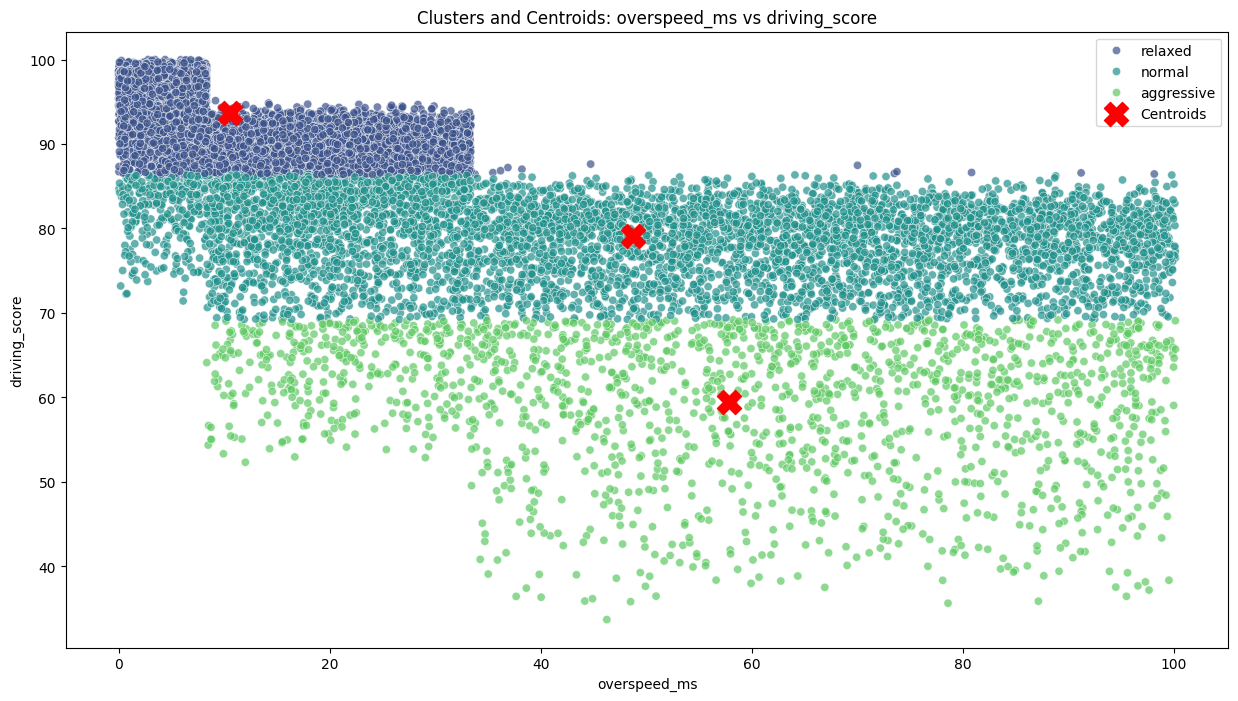

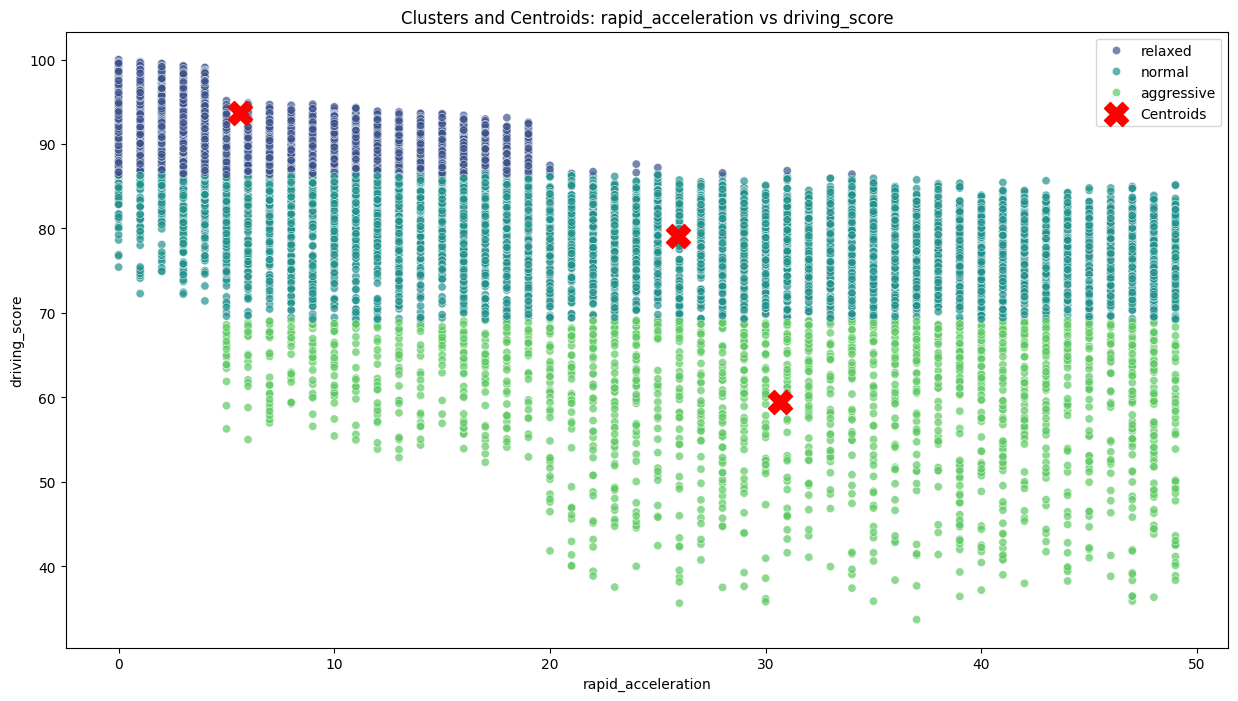

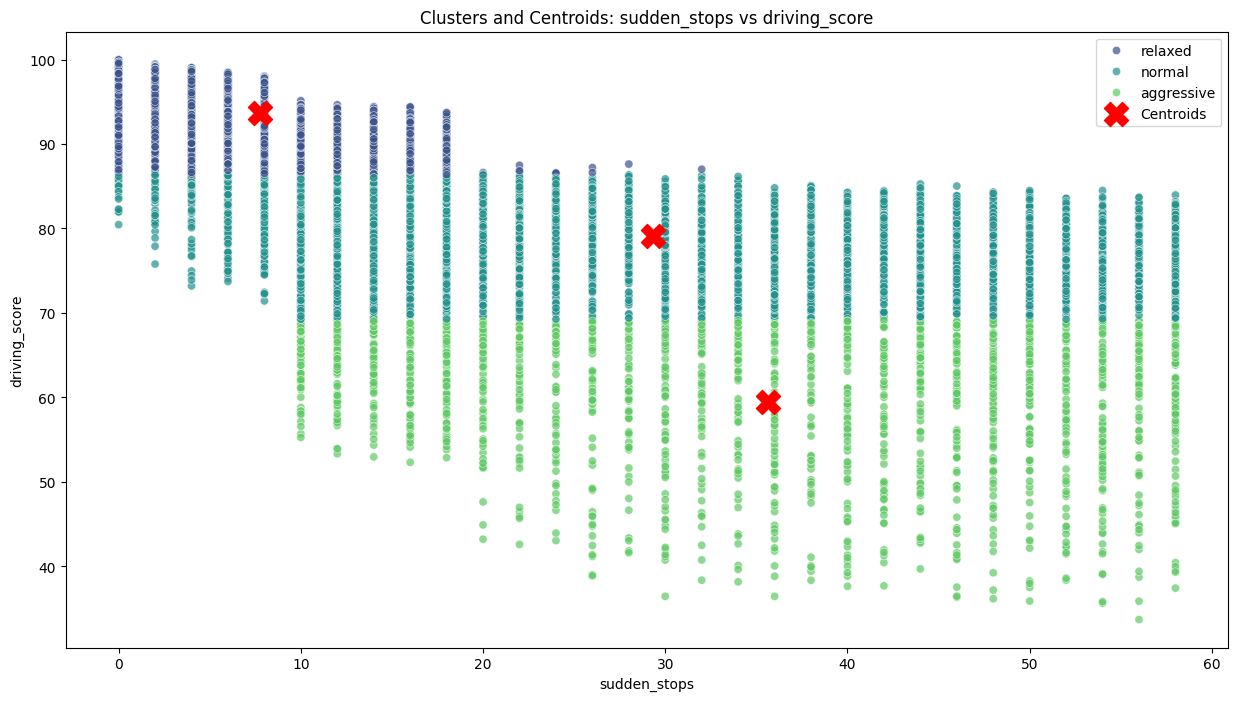

In [11]:
# Function to plot clusters with centroids
def plot_clusters(df, cluster_centers_df, feature1, feature2):
    plt.figure(figsize=(15, 8))
    sns.scatterplot(data=df, x=feature1, y=feature2, hue='driving_behavior', palette='viridis', alpha=0.7)
    plt.scatter(cluster_centers_df[feature1], cluster_centers_df[feature2], s=300, c='red', label='Centroids', marker='X')
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(f'Clusters and Centroids: {feature1} vs {feature2}')
    plt.legend()
    plt.show()

# Compute centroids for plotting
centroids_df = combined_df.groupby('driving_behavior').mean().reset_index()

# Plot clusters with centroids
plot_clusters(combined_df, centroids_df, 'overspeed_ms', 'driving_score')
plot_clusters(combined_df, centroids_df, 'rapid_acceleration', 'driving_score')
plot_clusters(combined_df, centroids_df, 'sudden_stops', 'driving_score')

**Clustering Evaluation**

This code section provides insights into the clustering results:

* **Data Preview:** It displays a few rows (`print(combined_df.head())`) and the overall size (`print(combined_df.shape)`) of the processed data.
* **Cluster Distribution:** It reveals how many data points belong to each cluster (`print("Cluster sizes:\n", cluster_sizes)`) to assess balance.
* **Clustering Quality:** It calculates the Silhouette score (`print("Silhouette Score of model:", silhouette_avg)`) to evaluate how well data points are grouped.

The Silhouette Coefficient is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b) for each sample. The Silhouette Coefficient for a sample is (b - a) / max(a, b). To clarify, b is the distance between a sample and the nearest cluster that the sample is not a part of. A silhouette score above 0.5 indicates a good clustering, a silhouette score below 0.25 indicates a bad clustering, and a silhouette score between 0.25 and 0.5 indicates a fair clustering

In [12]:
print(combined_df.head())
print(combined_df.shape)
cluster_sizes = combined_df['cluster'].value_counts()
print("Cluster sizes:\n", cluster_sizes)

# Calculate silhouette score
sil_score = silhouette_score(combined_df[['driving_score']], combined_df['cluster'])
print(f'Silhouette Score: {sil_score:.2f}')

   trip_distance_km  overspeed_ms  night_driving_ms  rapid_acceleration  \
0         62.478186      5.762944         11.285404                   1   
1         18.101889     29.668837         31.765946                  16   
2         58.988342      1.201628         20.776527                   3   
3         41.991587     33.898538         91.646343                  39   
4         63.299398     13.162629         58.784731                  17   

   sharp_turns  sudden_stops  trip_duration_ms  driving_score  cluster  \
0            3             8        697.806522      97.142615        0   
1           11            14       1162.831290      80.657548        1   
2            0             2        430.838529      98.455594        0   
3           24            20        588.266396      80.265037        1   
4            8            14       1423.990004      91.863285        0   

  driving_behavior  
0          relaxed  
1           normal  
2          relaxed  
3           normal  

**The data is labelled now and now we can train a classifier on this data to predict further incoming data and classify them as normal/aggressive/relaxed driving styles**
**KNN Classifier**

This section focuses on evaluating the performance of a K-Nearest Neighbors (KNN) classifier for predicting driving styles:

1. **Data Split:**
    * The code separates the processed data (`combined_df`) into features (`X`) and target labels (`y`). Features exclude the already identified cluster and predicted style columns (`'cluster'`, `'predicted_driving_style'`).
    * It utilizes `train_test_split` to create training and testing sets (`X_train`, `X_test`, `y_train`, `y_test`). A common split ratio of 80% for training and 20% for testing is used here (`test_size=0.2`).

2. **KNN Model Training:**
    * A KNN classifier object (`knn`) is created with a hyperparameter `n_neighbors=50`, specifying the number of neighbors to consider for classification.
    * The model is trained using `fit` on the training data (`X_train`, `y_train`).

3. **Prediction and Accuracy:**
    * The trained model predicts driving styles (`y_pred`) for the unseen test data (`X_test`).
    * The `accuracy_score` function calculates the overall accuracy of the KNN model on the test set, providing a measure of how well it generalizes to unseen data.

4. **Confusion Matrix Analysis:**
    * A confusion matrix (`confusion_matrix`) is created using `pd.crosstab`. It compares the actual driving styles in the test set (`y_test`) with the predicted styles (`y_pred`). This helps identify potential misclassifications and understand how well the model performs for each driving style category.

Accuracy: 0.96


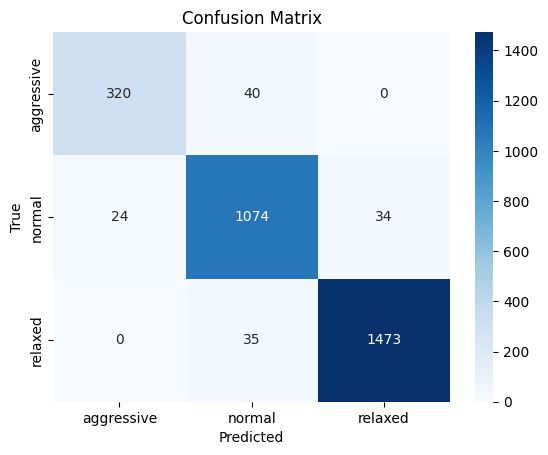

In [13]:
# Now you can use this labeled data to train a KNN classifier
# Define the features and the target
features = combined_df.drop(columns=['driving_score', 'driving_behavior', 'cluster'])
target = combined_df['driving_behavior']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Scale the features
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# Predict the labels on the test set
y_pred = knn.predict(X_test_scaled)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Visualize the results using a confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['aggressive', 'normal', 'relaxed'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['aggressive', 'normal', 'relaxed'], yticklabels=['aggressive', 'normal', 'relaxed'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


## Additional testing of KNN classifier using random data and calculating the accuracy

This code generates and processes additional data specifically for aggressive driving behavior:

**Function for Data Generation**: It utilizes the existing generate_driving_data2 function to create a dictionary containing various driving features for 5000 samples.

**Converting to DataFrame**: The dictionary is converted into a pandas DataFrame named additional_df.

**Scaling and Dimensionality Reduction (Existing Techniques)**: Similar to the original data, the code applies:
1.Down-weighting of night_driving_ms.
2.Scaling of features using the existing scaler (scaler).
3.Dimensionality reduction with PCA using the existing PCA object (pca).
The results are stored in scaled_additional_features and reduced_additional_features.

Accuracy of KNN classifier on additional data: 0.84


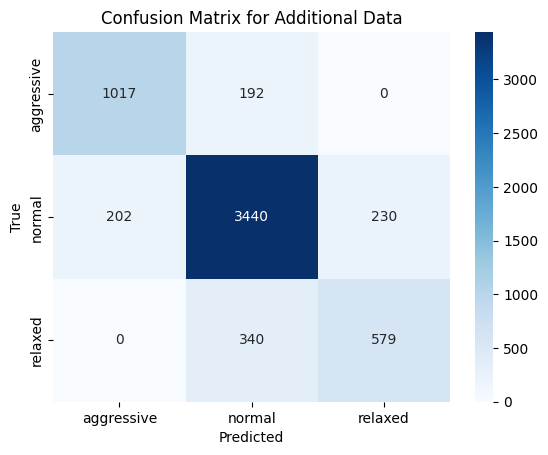

In [14]:
# Function to generate and test additional data
def generate_and_test_additional_data(num_samples):
    night_driving_ms = np.random.uniform(0, 3600000, num_samples)
    overspeed_ms = np.random.uniform(0, 600000, num_samples)
    trip_duration_ms = np.maximum(night_driving_ms, overspeed_ms) + np.random.uniform(0, 7200000, num_samples)
    additional_data = {
        "trip_distance_km": np.random.uniform(2, 70, num_samples),
        "overspeed_ms": overspeed_ms,
        "night_driving_ms": night_driving_ms,
        "rapid_acceleration": np.random.randint(0, 50, num_samples),
        "sharp_turns": np.random.randint(0, 50, num_samples),
        "sudden_stops": np.random.randint(0, 30, num_samples),
        "trip_duration_ms": trip_duration_ms
    }

    additional_df = pd.DataFrame(additional_data)
    
    # Apply the same scaling to the additional data
    additional_df['night_driving_ms'] = additional_df['night_driving_ms'] * 0.001 * 0.167 * 0.2
    additional_df['overspeed_ms'] = additional_df['overspeed_ms'] * 0.001 * 0.167
    additional_df['trip_duration_ms'] = additional_df['trip_duration_ms'] * 0.001 * 0.167
    additional_df['sudden_stops'] = additional_df['sudden_stops'] * 2 

    # Calculate driving scores for the additional data
    additional_df['driving_score'] = additional_df.apply(calculate_driving_score, axis=1)

    # Use the trained KMeans model to predict clusters on the additional data
    additional_df['cluster'] = kmeans.predict(additional_df[['driving_score']])
    additional_df['predicted_driving_behavior'] = additional_df['cluster'].map(cluster_labels)

    # Use the trained KNN model to predict driving behaviors on the additional data
    additional_features_scaled = scaler.transform(additional_df.drop(columns=['driving_score', 'predicted_driving_behavior', 'cluster']))
    additional_predictions = knn.predict(additional_features_scaled)

    # Calculate accuracy
    additional_accuracy = accuracy_score(additional_df['predicted_driving_behavior'], additional_predictions)
    print(f"Accuracy of KNN classifier on additional data: {additional_accuracy:.2f}")

    # Visualize the results using a confusion matrix
    additional_cm = confusion_matrix(additional_df['predicted_driving_behavior'], additional_predictions, labels=['aggressive', 'normal', 'relaxed'])
    sns.heatmap(additional_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['aggressive', 'normal', 'relaxed'], yticklabels=['aggressive', 'normal', 'relaxed'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix for Additional Data')
    plt.show()
# Generate and test additional data
generate_and_test_additional_data(6000)